In [1]:
# For processing the timeseries
import pandas as pd, os, datetime
import numpy as np

# For plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
pio.renderers.default = 'notebook'

In [2]:
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')

nmap_path = '/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess'
ehf_fpath = '/scratch/ng72/ms5578/time_series'
gen_fpath = '/scratch/ng72/ms5578/time_series/nem_generation'

In [3]:
gen_details = pd.read_csv(f"{nmap_path}/gen_info.csv")

In [4]:
# A temporary patch to fix fuel types
gen_details['fuel_source_primary'] = gen_details['fuel_source_primary'].replace({'Solar - Solar': 'Solar','Wind - Wind': 'Wind'})

In [5]:
hw_tseries = pd.read_csv(f"{ehf_fpath}/gen_hw_status.csv")

In [6]:
def process_group(grp, gen_fpath, hw_tseries, start_date=None, end_date=None):
    """
    Processes a single group of generator data.

    Parameters:
        grp (pd.DataFrame): A single group from gen_details (e.g., from groupby('region')).
        gen_fpath (str): Path to directory containing CSV files named by DUID (e.g., DUID.csv).
        hw_tseries (pd.DataFrame): DataFrame with columns 'time', 'DUID', and data to merge.
        start_date (str): Start date for subsetting the time series.
        end_date (str): End date for subsetting the time series.

    Returns:
        pd.DataFrame: The merged result for the group.
    """
    safe_duids = [duid.replace("/", "_").replace("\\", "_") for duid in grp['DUID']]
    gen_locs = [f"{gen_fpath}/{duid}.csv" for duid in safe_duids]
    dfs = [pd.read_csv(fp,dtype='object') for fp in gen_locs if os.path.exists(fp)]
    print(f"Loaded {len(dfs)} CSV file(s) out of {len(gen_locs)} expected.")

    if not dfs:
        return None

    # This is in case of accidental mid-file headers
    dfs = pd.concat(dfs, ignore_index=True)
    header_row = dfs.columns.tolist()
    dfs = dfs[~dfs.apply(lambda row: list(row) == header_row, axis=1)]

    # This is to correct the column types after removing header rows
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs['TOTALCLEARED'] = dfs['TOTALCLEARED'].astype(float)
    dfs['TOTALMWh'] = dfs['TOTALMWh'].astype(float)
    dfs['AGCSTATUS'] = pd.to_numeric(dfs['AGCSTATUS'], errors='coerce').fillna(0).astype(int)
    
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs = dfs.set_index('time').sort_index()
    dfs = dfs.loc[start_date:end_date]

    # Group by DUID and hourly time, sum TOTALMWh
    agg_func = {'TOTALMWh':'sum','TOTALCLEARED':'sum','AGCSTATUS':'min'}
    grouped = dfs.groupby(['DUID', pd.Grouper(freq='1d')]).agg(agg_func).reset_index()

    hw_tseries['time'] = pd.to_datetime(hw_tseries['time'])
    hw_tseries = hw_tseries.set_index(['time']).sort_index()
    hw_tseries = hw_tseries.loc[sdate:edate]
    hw_tseries = hw_tseries.reset_index().set_index(['DUID','time']).sort_index()

    merged = pd.merge_asof(
        grouped.sort_values(by=['time', 'DUID']),
        hw_tseries.sort_values(by=['time', 'DUID']),
        by='DUID',
        on='time',
        tolerance=pd.Timedelta("1d"),
        direction='nearest'
    )

    return merged

In [7]:
def select_group(gen_details=gen_details, state=None,ftype=None):
    if state is not None and ftype is not None:
        groups = gen_details.groupby(['region','fuel_source_primary'])
        grp = groups.get_group((state,ftype))
    elif state is not None:
        groups = gen_details.groupby('region')
        grp = groups.get_group(state)
    elif ftype is not None:
        groups = gen_details.groupby('fuel_source_primary')
        grp = groups.get_group(ftype)

    else:
        grp = gen_details

    return grp


In [55]:
def jitter(group):
    duplicates = group.groupby(['lat', 'lon']).cumcount()
    
    # Jitter function: add a small random offset
    np.random.seed(42)  # For reproducibility
    jitter_strength = 0.01  # Adjust as needed; degrees latitude/longitude
    
    group['lat_jittered'] = group['lat'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(group)) * duplicates
    group['lon_jittered'] = group['lon'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(group)) * duplicates

    return group

In [58]:
sdate, edate = '2018-12-01','2019-02-28'
# sdate, edate = '2016-06-01','2019-06-30'
group = select_group(state='NSW1').copy()
df = process_group(group, gen_fpath, hw_tseries,sdate,edate)

Loaded 49 CSV file(s) out of 124 expected.


In [59]:
df = df.merge(gen_details[['DUID', 'reg_cap_mw','technology_type_primary','fuel_source_primary']], on='DUID', how='left')
df['reg_cap_mw'] = df['reg_cap_mw'].astype('float') * 24
df['cap_norm'] = df['TOTALMWh']/df['reg_cap_mw']
df['min_max'] = df.groupby('DUID')['TOTALMWh'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
df = df[~((df['TOTALMWh'] < 0) | (df['cap_norm'] <0))]
# df = df[~((df['cap_norm'] > 1) | (df['cap_norm'] <0))]

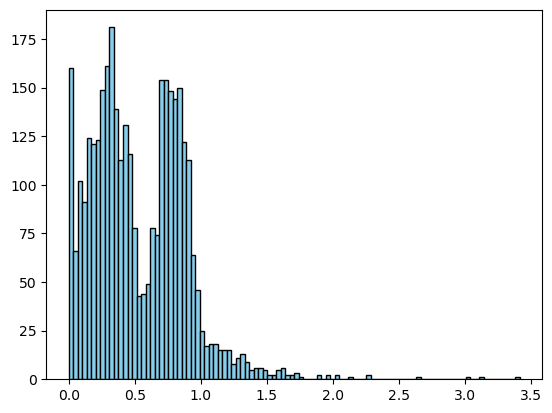

In [60]:
plt.hist(df[~(df['cap_norm'] == 0)]['cap_norm'], bins=100, color='skyblue', edgecolor='black');

In [61]:
# Step 1: Count non-heatwave (0) and heatwave (1) days per DUID
day_counts = df.groupby(['DUID', 'EHF_flag']).size().unstack(fill_value=0).reset_index()
day_counts.columns.name = None
day_counts = day_counts.rename(columns={0: 'no_hw', 1: 'in_hw'})

# Step 2: Merge with fuel source info
day_counts = day_counts.merge(group[['DUID', 'fuel_source_primary']], on='DUID')

# Step 3: Sort for visual grouping
day_counts = day_counts.sort_values(by=['fuel_source_primary', 'DUID'])

# Step 4: Assign consistent color per fuel type
fuel_types = day_counts['fuel_source_primary'].unique()
color_palette = px.colors.qualitative.Set2
color_map = {fuel: color_palette[i % len(color_palette)] for i, fuel in enumerate(fuel_types)}
day_counts['color'] = day_counts['fuel_source_primary'].map(color_map)

# Step 5: Create stacked bars
fig = go.Figure()

# --- Non-heatwave bars (solid color) ---
fig.add_trace(go.Bar(
    x=day_counts['DUID'],
    y=day_counts['no_hw'],
    name='Not in Heatwave',
    marker_color=day_counts['color'],
    customdata=day_counts[['fuel_source_primary']],
    hovertemplate=(
        '<b>DUID:</b> %{x}<br>' +
        '<b>Days (Not in HW):</b> %{y}<br>' +
        '<b>Fuel:</b> %{customdata[0]}<extra></extra>'
    )
))

# --- Heatwave bars (same color, with hatching) ---
fig.add_trace(go.Bar(
    x=day_counts['DUID'],
    y=day_counts['in_hw'],
    name='In Heatwave',
    marker=dict(
        color='#798b94',
        pattern=dict(shape='x', solidity=0.7)  # hatch fill
    ),
    customdata=day_counts[['fuel_source_primary']],
    hovertemplate=(
        '<b>DUID:</b> %{x}<br>' +
        '<b>Days (In HW):</b> %{y}<br>' +
        '<b>Fuel:</b> %{customdata[0]}<extra></extra>'
    )
))

# Step 6: Layout settings
fig.update_layout(
    title='Heatwave vs Non-Heatwave Days by Generator (Colored by Fuel Type, Hatching in HW)',
    xaxis_title='Generator (DUID)',
    yaxis_title='Number of Days',
    barmode='stack',
    height=600,
    xaxis=dict(
        tickmode='array',
        tickvals=day_counts['DUID'],
        ticktext=day_counts['DUID'],
        tickangle=90
    ),
    legend=dict(
        title='Legend',
        traceorder='normal'
    )
)

fig.show()


In [62]:
# --- 1. Group data ---
# % of generators in/out of heatwave
gens_in_hw = df.groupby('time')['EHF_flag'].value_counts().unstack(fill_value=0)
gens_percent = gens_in_hw.div(gens_in_hw.sum(axis=1), axis=0) * 100

# Total generation split by EHF_flag
gen_split = df.groupby(['time', 'EHF_flag'])['TOTALMWh'].sum().unstack(fill_value=0)

import plotly.graph_objects as go

# --- Heatwave Participation (% stacked bars) ---
fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=gens_percent.index.astype(str),
    y=gens_percent[0],
    name='Not in Heatwave (%)',
    marker_color='lightblue'
))

fig1.add_trace(go.Bar(
    x=gens_percent.index.astype(str),
    y=gens_percent[1],
    name='In Heatwave (%)',
    marker_color='tomato'
))

fig1.update_layout(
    title='Percentage of Generators in Heatwave per Day',
    xaxis_title='Date',
    yaxis_title='Participation (%)',
    barmode='stack',
    yaxis=dict(ticksuffix='%'),
    height=400,
    legend=dict(title='EHF_flag')
)

fig1.show()


In [93]:
avg_output = df.groupby(['DUID', 'EHF_flag'])['TOTALMWh'].mean().unstack()
avg_output.columns = ['avg_non_hw', 'avg_hw']
avg_output['diff'] = avg_output['avg_hw'] - avg_output['avg_non_hw']
avg_output['ratio'] = avg_output['avg_hw'] / avg_output['avg_non_hw']
avg_output_sorted = avg_output.sort_values('diff', ascending=False)
# Extract unique generator_id and fuel_source_primary mapping
fuel_map = df[['DUID', 'fuel_source_primary']].drop_duplicates()
avg_output = avg_output.reset_index().merge(fuel_map, on='DUID')

In [64]:
fig = px.bar(
    avg_output,
    x='DUID',
    y='ratio',
    color='fuel_source_primary',
    title='Difference in Average Generation (Heatwave vs Non-Heatwave) in MWh',
    labels={'diff': 'Difference in Avg Generation', 'generator_id': 'Generator'},
    height=500
)

# Optional: sort bars by diff descending
fig.update_layout(
    xaxis={'categoryorder':'total descending'}
)

fig.show()


In [100]:
# 1. Calculate average generation per generator

# 2. Map average back to original df
df['avg_non_hw'] = df['DUID'].map(avg_output['avg_non_hw'])

# 3. Calculate deviation from average
df['deviation_from_avg'] = df['TOTALMWh']/df['avg_non_hw']

df['clear_deficit'] = df['TOTALMWh'] - df['TOTALCLEARED']

In [66]:
# Step 1: Compute heatwave percentage per day
total_by_day = df.groupby('time')['DUID'].nunique()
hw_by_day = df[df['EHF_flag'] == 1].groupby('time')['DUID'].nunique()
hw_percent = (hw_by_day / total_by_day * 100).fillna(0).reset_index(name='hw_percent')

In [67]:
# # Step 2: Create empty figure and add shaded area first
# fig = go.Figure()

# # Add shaded heatwave percentage trace first (so it’s in background)
# fig.add_trace(go.Scatter(
#     x=hw_percent['time'],
#     y=hw_percent['hw_percent'],
#     fill='tozeroy',
#     mode='none',
#     fillcolor='rgba(255, 100, 100, 0.2)',
#     name='% in Heatwave (shading)',
#     yaxis='y2',  # Uses secondary axis
#     hoverinfo='x+y'
# ))

# # Step 3: Add bar chart on top
# bar_fig = px.bar(
#     df,
#     x='time',
#     y='deviation_from_avg',
#     color='fuel_source_primary',
#     labels={'deviation_from_avg': 'Deviation from Avg', 'time': 'Date'},
# )

# # Append bar traces to existing figure
# for trace in bar_fig.data:
#     fig.add_trace(trace)

# # Step 4: Layout adjustments
# fig.update_layout(
#     yaxis=dict(title='Deviation from Avg (%)', ticksuffix='%'),
#     yaxis2=dict(
#         title='% in Heatwave',
#         overlaying='y',
#         side='right',
#         range=[0, 100],
#         ticksuffix='%',
#         showgrid=False
#     ),
#     xaxis_title='Date',
#     barmode='stack',
#     height=600,
#     legend_title='Legend',
#     legend=dict(
#         x=1.2,  # Place legend to the right
#         y=1,
#         xanchor='left',
#         yanchor='top'
#         ),
#     title='Generation Deviation from Non-Heatwave Average with Heatwave Shading'
# )

# fig.show()


In [68]:
agg_func = {'clear_deficit':'sum','fuel_source_primary':'first','EHF_val':'first','EHF_flag':'first'}
cleared_by_day = df.groupby(['DUID','time']).agg(agg_func).reset_index()

In [69]:
# Step 1: Create base figure
fig = go.Figure()

# Step 2: Add shaded heatwave area trace (background)
fig.add_trace(go.Scatter(
    x=hw_percent['time'],
    y=hw_percent['hw_percent'],
    fill='tozeroy',
    mode='none',
    fillcolor='rgba(255, 100, 100, 0.2)',
    name='% in Heatwave (shading)',
    yaxis='y2',
    hoverinfo='x+y'
))

# Step 3: Create bar chart using Plotly Express
bar_fig = px.bar(
    cleared_by_day,
    x='time',
    y='clear_deficit',
    color='fuel_source_primary',
    hover_data=['DUID'],
    labels={
        'clear_deficit': 'Difference (MWh)',
        'time': 'Date',
        'fuel_source_primary': 'Fuel Source',
        'DUID':'DUID'
    }
)

# Step 4: Append bar traces from bar_fig into fig
for trace in bar_fig.data:
    fig.add_trace(trace)

# Step 5: Final layout adjustments
fig.update_layout(
    yaxis=dict(
        title='Difference between cleared and actual generation',
        ticksuffix=' MWh'
    ),
    yaxis2=dict(
        title='% in Heatwave',
        overlaying='y',
        ticksuffix='%',
        side='right',
        range=[0, 100],
        showgrid=False
    ),
    xaxis_title='Date',
    barmode='stack',  # Ensure bars are stacked by color
    height=600,
    legend_title='Fuel Source',
    title='Difference from Cleared and Actual Generation (MWh) with Heatwave Shading',
    legend=dict(
        x=1.2,  # Place legend to the right
        y=1,
        xanchor='left',
        yanchor='top'
    )
)

# Step 6: Show the figure
fig.show()

In [70]:
agg_func = {'clear_deficit':'sum'}
cleared_daily = df.groupby(['time','fuel_source_primary']).agg(agg_func).reset_index()

In [71]:
# Create base figure with line chart
fig = px.line(
    cleared_daily,
    x='time',
    y='clear_deficit',
    color='fuel_source_primary',
    labels={
        'time': 'Date',
        'clear_deficit': 'Clear Deficit (MWh)',
        'fuel_source_primary': 'Fuel Source'
    },
    title='Daily Clear Deficit by Fuel Source'
)

# Add shaded heatwave area using secondary y-axis
fig.add_trace(go.Scatter(
    x=hw_percent['time'],
    y=hw_percent['hw_percent'],
    fill='tozeroy',
    mode='none',
    fillcolor='rgba(255, 100, 100, 0.2)',
    name='% in Heatwave (shading)',
    yaxis='y2',
    hoverinfo='x+y'
))

# Update layout to define yaxis2
fig.update_layout(
    yaxis=dict(
        title='Clear Deficit (MWh)'
    ),
    yaxis2=dict(
        title='% in Heatwave',
        overlaying='y',
        side='right',
        ticksuffix='%',
        range=[0, 100],  # adjust based on your data
        showgrid=False
    ),
    xaxis_title='Date',
    height=600,
    legend_title='Fuel Source',
        legend=dict(
        x=1.2,  # Place legend to the right
        y=1,
        xanchor='left',
        yanchor='top'
    )
)

fig.show()


In [72]:
# Filter data
filtered_df = cleared_by_day[cleared_by_day['EHF_flag'] != 0].copy()

# Get unique fuel types and generate consistent color mapping
fuel_types = filtered_df['fuel_source_primary'].unique()
color_map = px.colors.qualitative.Plotly  # Default plotly palette
fuel_color = {fuel: color_map[i % len(color_map)] for i, fuel in enumerate(fuel_types)}

# Initialize figure
fig = go.Figure()

# Loop through each fuel type
for fuel in fuel_types:
    df_fuel = filtered_df[filtered_df['fuel_source_primary'] == fuel]

    if len(df_fuel) >= 2:
        x = df_fuel['EHF_val']
        y = df_fuel['clear_deficit']
        coeffs = np.polyfit(x, y, 1)
        fit_line = np.poly1d(coeffs)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = fit_line(x_fit)

        # Scatter points
        fig.add_trace(go.Scatter(
            x=x,
            y=y,
            mode='markers',
            name=f'{fuel} (points)',
            marker=dict(size=6, color=fuel_color[fuel]),
            hovertext=df_fuel['DUID'],
            legendgroup=fuel,
            showlegend=True
        ))

        # Line of best fit
        fig.add_trace(go.Scatter(
            x=x_fit,
            y=y_fit,
            mode='lines',
            name=f'{fuel} (fit)',
            line=dict(color=fuel_color[fuel], dash='dash'),
            legendgroup=fuel,
            showlegend=False  # Hide to avoid legend clutter
        ))

fig.update_layout(
    title='Cleared vs Actual Generation Gap for Non-zero EHF Days',
    xaxis_title='EHF Value',
    yaxis_title='Difference (MWh)',
    height=600,
    legend_title='Fuel Source'
)

fig.show()


In [73]:
df['in_hw'] = df['EHF_flag'].map({1: 'Heatwave', 0: 'Non-Heatwave'})

# Step 3: Create violin plot grouped by fuel type and split by heatwave status
fig = px.violin(
    df,
    x='fuel_source_primary',
    y='min_max',
    color='in_hw',
    box=True,
    points='all',
    hover_data=['DUID', 'time','TOTALMWh'],
    labels={
        'fuel_source_primary': 'Fuel Source',
        'gen_pct_of_cap': 'Generation (% of Registered Capacity)',
        'in_hw': 'Condition',
        'TOTALMWh':'Daily Generation (MWh)'
    },
    title='Daily Normalised Generation: Heatwave vs Non-Heatwave by Fuel Source',
)

fig.update_layout(
    yaxis_title='Min-max Normalised Daily Generation',
    xaxis_title='Fuel Source',
    height=600,
    legend_title='Condition'
)

fig.show()


In [74]:
fig = px.scatter(
    avg_output,
    x='avg_non_hw',
    y='avg_hw',
    color='fuel_source_primary',
    hover_name='DUID',
    labels={
        'non_hw_avg': 'Avg Deviation (Non-Heatwave)',
        'in_hw_avg': 'Avg Deviation (Heatwave)',
        'fuel_source_primary': 'Fuel Type'
    },
    title='Average Generation: Heatwave vs Non-Heatwave by Generator'
)

fig.update_layout(
    height=600,
    xaxis_title='Avg Generation on Non-Heatwave Days',
    yaxis_title='Avg Generation on Heatwave Days',
    legend_title='Fuel Source'
)

fig.show()


In [75]:
# Step 1: Aggregate generation by time and fuel
gen_by_fuel = df.groupby(['time', 'fuel_source_primary'])['TOTALMWh'].sum().reset_index()

# Step 2: Calculate total generation per time
total_gen = df.groupby('time')['TOTALMWh'].sum().reset_index().rename(columns={'TOTALMWh': 'total_generation'})

# Step 3: Merge to compute % share
gen_share = pd.merge(gen_by_fuel, total_gen, on='time')
gen_share['percent_share'] = 100 * gen_share['TOTALMWh'] / gen_share['total_generation']

# Step 4: Plot as area or line chart
fig = px.area(
    gen_share,
    x='time',
    y='percent_share',
    color='fuel_source_primary',
    labels={
        'time': 'Date',
        'percent_share': 'Market Share (%)',
        'fuel_source_primary': 'Fuel Source'
    },
    title='Daily Generation Market Share by Fuel Source (%)'
)

fig.update_layout(
    yaxis_title='Market Share (%)',
    xaxis_title='Date',
    height=600,
    legend_title='Fuel Source'
)

fig.add_trace(go.Scatter(
    x=hw_percent['time'],
    y=hw_percent['hw_percent'],
    mode='lines',
    line=dict(color='red', dash='dash'),
    name='% in Heatwave',
    yaxis='y2',
    hoverinfo='x+y'
))

# --- Step 4: Configure secondary y-axis and layout ---
fig.update_layout(
    yaxis=dict(
        title='Market Share (%)',
        range=[0, 100]
    ),
    yaxis2=dict(
        title='% in Heatwave',
        overlaying='y',
        side='right',
        range=[0, 100],
        showgrid=False
    ),
    xaxis_title='Date',
    height=600,
    legend_title='Fuel Source'
)


fig.show()


In [109]:
by_unit = jitter(by_unit)

fig = px.scatter_map(
    by_unit,
    lat='lat_jittered',
    lon='lon_jittered',
    hover_name='DUID',
    hover_data=['DUID','fuel_source_primary'],
    labels={
        'fuel_source_primary': 'Fuel Source',
    },
    zoom=5,
    color='diff',
    map_style='open-street-map'
)
fig.show()

In [150]:
clear_by_unit = cleared_by_day.groupby(['DUID','EHF_flag']).agg(
                    avg_clear=('clear_deficit','mean'),
                    tot_clear=('clear_deficit','sum')
                ).unstack()

clear_by_unit.columns = ['avg_non_hw', 'avg_hw','tot_non_hw','tot_hw']

clear_by_unit['diff_in_avg'] = clear_by_unit['avg_hw'] - clear_by_unit['avg_non_hw']
clear_by_unit['diff_in_tot'] = clear_by_unit['tot_hw'] - clear_by_unit['tot_non_hw']

clear_by_unit = clear_by_unit.reset_index().merge(group[['DUID','fuel_source_primary','lat','lon']], on='DUID')

clear_by_unit = jitter(clear_by_unit)

min_size = 3
max_size = 30

sizes = clear_by_unit['diff_in_avg'].abs()
if sizes.max() > 0:
    normalized_sizes = (sizes - sizes.min()) / (sizes.max() - sizes.min())
    clear_by_unit['marker_size'] = normalized_sizes * (max_size - min_size) + min_size
else:
    clear_by_unit['marker_size'] = min_size

fig7 = px.scatter_map(
    clear_by_unit,
    lat='lat_jittered',
    lon='lon_jittered',
    hover_name='DUID',
    hover_data=['DUID', 'fuel_source_primary'],
    size=clear_by_unit['marker_size'],
    color='diff_in_avg',
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0,
    labels={'fuel_source_primary': 'Fuel Source'},
    zoom=5,
    map_style='carto-darkmatter'
)

fig7.show()